# Day 5 Lab — Formal Granger/VAR and Contextual Anomaly Analysis

This notebook now follows the restored Day 5 agenda more directly:
1. compare **correlation** with formal **pairwise Granger** evidence,
2. fit a multivariate **VAR** and inspect residual anomalies,
3. compare **global** and **context-aware** thresholds,
4. stage held-out alerts into events,
5. produce a **context-graph-style** review artifact,
6. and optionally compare the learned graph with a **Tigramite / PCMCI** run.

Still be cautious:
- Granger and VAR add formal statistical tests, but they still do **not** prove intervention-level causality,
- residuals remain an investigation aid rather than a root-cause engine,
- and PCMCI is a stronger conditional-independence comparison, not a magic truth oracle.

## Real-data schema
- required: `timestamp`, `context`, and 2 or more metric columns
- optional: `is_anomaly`


In [22]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

try:
    import statsmodels.api as sm
    from statsmodels.tsa.api import VAR
except ModuleNotFoundError as exc:
    if exc.name == 'statsmodels':
        raise ModuleNotFoundError(
            "Missing required package 'statsmodels'. Install the lab requirements "
            "inside the active notebook kernel, then restart the kernel:\n"
            "    %pip install -r ../requirements.txt\n"
            "From a terminal in the pack root, use:\n"
            "    python -m pip install -r requirements.txt"
        ) from exc
    raise

try:
    from tigramite import data_processing as pp
    from tigramite.pcmci import PCMCI
    from tigramite.independence_tests.parcorr import ParCorr
    TIGRAMITE_AVAILABLE = True
except Exception:
    pp = PCMCI = ParCorr = None
    TIGRAMITE_AVAILABLE = False

warnings.filterwarnings('ignore', message='verbose is deprecated', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 23
random.seed(SEED)
np.random.seed(SEED)

CSV_PATH = None  # replace with a local CSV path when moving to real data
EXPORT_FIGURES = True
TRAIN_FRAC = 0.70
MAX_GRANGER_LAG = 3
MAX_VAR_LAG = 6
ALPHA_LEVEL = 0.05
PCMCI_PC_ALPHA = 0.20

def resolve_pack_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / 'notebooks').exists() and (candidate / 'slides').exists():
            return candidate
    return cwd

PACK_ROOT = resolve_pack_root()
FIG_DIR = PACK_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('CSV_PATH =', CSV_PATH)
print('TIGRAMITE_AVAILABLE =', TIGRAMITE_AVAILABLE)


CSV_PATH = None
TIGRAMITE_AVAILABLE = True


## Step 1 — Load a regime-aware panel

The synthetic demo is constructed so that:
- the training period contains a long noisy **high-load** regime,
- the held-out period contains anomalies in a quieter **low-load** regime,
- and the comparison between global and context-aware thresholding is therefore teachable.

In [23]:
def make_synthetic_panel(n=1500, freq='1min'):
    ts = pd.date_range('2024-01-01', periods=n, freq=freq)
    regime = np.array(['high_load'] * n, dtype=object)
    regime[:220] = 'low_load'
    regime[1050:] = 'low_load'

    m1 = np.zeros(n)
    m2 = np.zeros(n)
    m3 = np.zeros(n)
    label = np.zeros(n, dtype=int)

    for t in range(1, n):
        high = regime[t] == 'high_load'
        ctx_shift = 0.24 if high else -0.03
        noise = 0.13 if high else 0.03
        m1[t] = 0.80 * m1[t - 1] + 0.18 * np.sin(t / 22.0) + ctx_shift + np.random.normal(0, noise)
        m2[t] = 0.58 * m2[t - 1] + 0.34 * m1[t - 1] + 0.10 * ctx_shift + np.random.normal(0, noise * 0.9)
        m3[t] = 0.52 * m3[t - 1] + 0.36 * m2[t - 1] + 0.07 * ctx_shift + np.random.normal(0, noise * 0.8)

    m1[1140:1175] += 1.15
    m2[1143:1178] += 0.90
    m3[1148:1180] += 0.45
    label[1140:1180] = 1

    m3[1340:1385] -= 1.15
    label[1340:1385] = 1

    return pd.DataFrame({
        'timestamp': ts,
        'context': regime,
        'm1': m1,
        'm2': m2,
        'm3': m3,
        'is_anomaly': label,
    })


def load_panel(csv_path=None):
    if csv_path and Path(csv_path).exists():
        df = pd.read_csv(csv_path, parse_dates=['timestamp']).sort_values('timestamp')
        if 'context' not in df.columns:
            raise ValueError('CSV must contain a context column for this lab.')
        if 'is_anomaly' not in df.columns:
            df['is_anomaly'] = 0
        return df
    return make_synthetic_panel()


panel_df = load_panel(CSV_PATH)
metric_cols = [c for c in panel_df.columns if c not in {'timestamp', 'context', 'is_anomaly'}]
print(panel_df.head())
print('metrics =', metric_cols)
print(panel_df['context'].value_counts())

            timestamp   context        m1        m2        m3  is_anomaly
0 2024-01-01 00:00:00  low_load  0.000000  0.000000  0.000000           0
1 2024-01-01 00:01:00  low_load -0.001811 -0.002303 -0.020763           0
2 2024-01-01 00:02:00  low_load  0.013351  0.013994 -0.038952           0
3 2024-01-01 00:03:00  low_load -0.005876 -0.021056 -0.049049           0
4 2024-01-01 00:04:00  low_load  0.051014 -0.026592 -0.019102           0
metrics = ['m1', 'm2', 'm3']
context
high_load    830
low_load     670
Name: count, dtype: int64


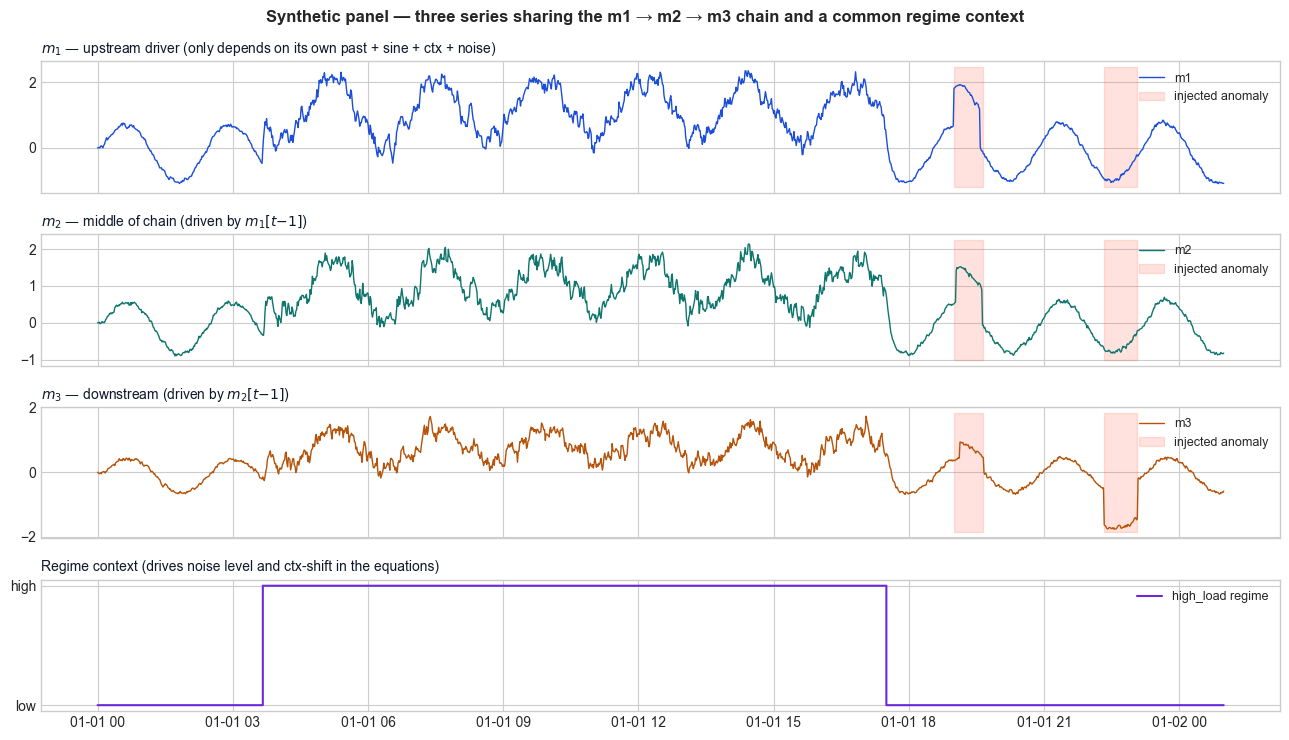

In [24]:
metric_colors = {'m1': '#1d4ed8', 'm2': '#0f766e', 'm3': '#b45309'}
metric_titles = {
    'm1': r'$m_1$ — upstream driver (only depends on its own past + sine + ctx + noise)',
    'm2': r'$m_2$ — middle of chain (driven by $m_1[t{-}1]$)',
    'm3': r'$m_3$ — downstream (driven by $m_2[t{-}1]$)',
}
fig, axes = plt.subplots(len(metric_cols) + 1, 1, figsize=(13, 7.5), sharex=True)
for ax, col in zip(axes[:-1], metric_cols):
    ax.plot(panel_df['timestamp'], panel_df[col], lw=1.0, color=metric_colors[col], label=col)
    ax.fill_between(
        panel_df['timestamp'],
        panel_df[col].min() - 0.1,
        panel_df[col].max() + 0.1,
        where=panel_df['is_anomaly'].astype(bool),
        color='tomato',
        alpha=0.18,
        label='injected anomaly',
    )
    ax.set_title(metric_titles[col], fontsize=10, loc='left', color='#0f172a')
    ax.legend(loc='upper right', fontsize=9, frameon=False)

context_numeric = (panel_df['context'] == 'high_load').astype(int)
axes[-1].step(panel_df['timestamp'], context_numeric, where='post', color='#6d28d9', label='high_load regime')
axes[-1].set_yticks([0, 1], ['low', 'high'])
axes[-1].set_title('Regime context (drives noise level and ctx-shift in the equations)',
                   fontsize=10, loc='left', color='#0f172a')
axes[-1].legend(loc='upper right', fontsize=9, frameon=False)
fig.suptitle('Synthetic panel — three series sharing the m1 → m2 → m3 chain and a common regime context',
             fontsize=12, fontweight='bold')
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day5_regime_overview.png', dpi=160, bbox_inches='tight')
plt.show()

### Teaching guardrail

Tell learners explicitly:
- raw **correlation** is not the same thing as directional evidence,
- pairwise **Granger** tests are still vulnerable to confounding, nonstationarity, and bad lag choices,
- the **VAR residual** score is an investigation aid,
- the report is a **held-out review artifact**, not formal causal proof,
- and **PCMCI** is a stronger conditional-independence comparison, not a license to overclaim.


In [25]:
def pairwise_correlation_matrix(df, columns):
    return df[columns].corr().abs()


def edge_table_from_matrix(matrix, value_name):
    rows = []
    for source in matrix.index:
        for target in matrix.columns:
            if source == target:
                continue
            rows.append({
                'source': source,
                'target': target,
                value_name: float(matrix.loc[source, target]),
            })
    return pd.DataFrame(rows).sort_values(value_name, ascending=False)


def granger_matrix(df, columns, maxlag=3):
    score_mat = pd.DataFrame(0.0, index=columns, columns=columns)
    pval_mat = pd.DataFrame(1.0, index=columns, columns=columns)
    lag_mat = pd.DataFrame(0, index=columns, columns=columns, dtype=int)
    fstat_mat = pd.DataFrame(0.0, index=columns, columns=columns)
    rows = []
    for source in columns:
        for target in columns:
            if source == target:
                continue
            test_data = df[[target, source]].dropna()
            try:
                tests = sm.tsa.stattools.grangercausalitytests(test_data, maxlag=maxlag, verbose=False)
                candidates = []
                for lag, out in tests.items():
                    f_stat, p_value, df_denom, df_num = out[0]['ssr_ftest']
                    candidates.append((float(p_value), int(lag), float(f_stat), float(df_denom), float(df_num)))
                best_p, best_lag, best_f, df_denom, df_num = min(candidates, key=lambda row: row[0])
                score = max(0.0, -np.log10(best_p + 1e-12))
                score_mat.loc[source, target] = score
                pval_mat.loc[source, target] = best_p
                lag_mat.loc[source, target] = best_lag
                fstat_mat.loc[source, target] = best_f
                rows.append({
                    'source': source,
                    'target': target,
                    'best_lag': best_lag,
                    'f_stat': best_f,
                    'p_value': best_p,
                    'granger_score': score,
                    'significant': bool(best_p < ALPHA_LEVEL),
                })
            except Exception as exc:
                rows.append({
                    'source': source,
                    'target': target,
                    'best_lag': np.nan,
                    'f_stat': np.nan,
                    'p_value': np.nan,
                    'granger_score': np.nan,
                    'significant': False,
                    'error': str(exc),
                })
    table = pd.DataFrame(rows).sort_values(['p_value', 'f_stat'], ascending=[True, False], na_position='last')
    return score_mat, pval_mat, lag_mat, fstat_mat, table


def fit_var_and_residuals(df, columns, train_index, maxlags=6, ic='aic'):
    train_df = df.loc[train_index, columns].copy()
    model = VAR(train_df)
    selected_lag = None
    try:
        order = model.select_order(maxlags=maxlags)
        selected_lag = order.selected_orders.get(ic)
    except Exception:
        selected_lag = None
    if selected_lag is None or int(selected_lag) < 1:
        selected_lag = min(maxlags, 3)
        selected_lag = max(1, int(selected_lag))
    var_res = model.fit(int(selected_lag))

    full_values = df[columns].to_numpy(dtype=float)
    preds = []
    for t in range(var_res.k_ar, len(df)):
        pred = var_res.intercept.copy()
        for lag in range(1, var_res.k_ar + 1):
            pred += var_res.coefs[lag - 1] @ full_values[t - lag]
        preds.append(pred)
    pred_df = pd.DataFrame(preds, index=df.index[var_res.k_ar:], columns=columns)
    aligned = df[columns].iloc[var_res.k_ar:]
    residuals = aligned - pred_df
    residual_score = pd.Series(np.linalg.norm(residuals.to_numpy(), axis=1), index=aligned.index, name='var_residual_score')

    whiteness_nlags = max(var_res.k_ar + 1, min(12, var_res.k_ar * 2 + 2))
    try:
        whiteness = var_res.test_whiteness(nlags=whiteness_nlags)
        whiteness_pvalue = float(whiteness.pvalue)
    except Exception:
        whiteness_pvalue = np.nan

    diagnostics = pd.DataFrame([{
        'selected_lag': int(var_res.k_ar),
        'aic': float(var_res.aic),
        'bic': float(var_res.bic),
        'hqic': float(var_res.hqic),
        'is_stable': bool(var_res.is_stable(verbose=False)),
        'whiteness_pvalue': whiteness_pvalue,
    }])
    return var_res, residuals, residual_score, diagnostics


def var_parent_strength_matrix(var_res, columns):
    summed = np.abs(var_res.coefs).sum(axis=0).T
    mat = pd.DataFrame(summed, index=columns, columns=columns)
    for col in columns:
        mat.loc[col, col] = 0.0
    return mat


def var_causality_table(var_res, columns):
    score_mat = pd.DataFrame(0.0, index=columns, columns=columns)
    pval_mat = pd.DataFrame(1.0, index=columns, columns=columns)
    rows = []
    for source in columns:
        for target in columns:
            if source == target:
                continue
            try:
                test = var_res.test_causality(target, [source], kind='f')
                p_value = float(test.pvalue)
                f_stat = float(test.test_statistic)
                score = max(0.0, -np.log10(p_value + 1e-12))
                score_mat.loc[source, target] = score
                pval_mat.loc[source, target] = p_value
                rows.append({
                    'source': source,
                    'target': target,
                    'f_stat': f_stat,
                    'p_value': p_value,
                    'var_score': score,
                    'significant': bool(p_value < ALPHA_LEVEL),
                })
            except Exception as exc:
                rows.append({
                    'source': source,
                    'target': target,
                    'f_stat': np.nan,
                    'p_value': np.nan,
                    'var_score': np.nan,
                    'significant': False,
                    'error': str(exc),
                })
    table = pd.DataFrame(rows).sort_values(['p_value', 'f_stat'], ascending=[True, False], na_position='last')
    return score_mat, pval_mat, table


def base_panel_score(df, columns, span=24):
    centered = df[columns] - df[columns].ewm(span=span, adjust=False).mean()
    scale = df[columns].ewm(span=span, adjust=False).std().replace(0, np.nan)
    return (centered / scale).abs().fillna(0.0).mean(axis=1)


def context_thresholds(scores, context, train_index, q=0.99):
    context = context.reindex(scores.index)
    train_scores = scores.loc[train_index]
    train_context = context.loc[train_index]
    thresholds = pd.Series(index=scores.index, dtype=float)
    fallback = float(train_scores.quantile(q))
    for regime, idx in train_context.groupby(train_context).groups.items():
        thresholds.loc[context == regime] = float(train_scores.loc[idx].quantile(q))
    return thresholds.fillna(fallback)


def zscore(series):
    return (series - series.mean()) / (series.std() + 1e-8)


def point_metrics(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


def event_ids_from_alerts(alerts):
    event_ids = []
    current = 0
    prev = 0
    for flag in alerts.astype(int):
        if flag == 1 and prev == 0:
            current += 1
        event_ids.append(current if flag == 1 else 0)
        prev = flag
    return pd.Series(event_ids, index=alerts.index)


def heldout_event_report(summary, residuals, granger_pvals, var_strength, var_pvals, test_index, alpha_level=0.05, top_k=8):
    heldout = summary.loc[test_index].copy()
    heldout = heldout[heldout['context_alert'] == 1].copy()
    if heldout.empty:
        return pd.DataFrame(columns=[
            'event_id', 'start', 'end', 'peak_timestamp', 'peak_score', 'context',
            'dominant_metric', 'max_abs_residual', 'granger_upstream',
            'var_parent_candidate', 'upstream_candidate', 'granger_pvalue', 'var_parent_strength'
        ])

    heldout['event_id'] = event_ids_from_alerts(heldout['context_alert'])
    rows = []
    for event_id, group in heldout.groupby('event_id'):
        if event_id == 0:
            continue
        peak_ts = group['fused_score'].idxmax()
        dominant_metric = residuals.loc[peak_ts].abs().idxmax()

        granger_ranked = granger_pvals[dominant_metric].drop(labels=[dominant_metric], errors='ignore').sort_values()
        var_ranked = var_pvals[dominant_metric].drop(labels=[dominant_metric], errors='ignore').sort_values()

        granger_candidate = granger_ranked.index[0] if len(granger_ranked) and granger_ranked.iloc[0] < alpha_level else 'none'
        var_candidate = var_ranked.index[0] if len(var_ranked) and var_ranked.iloc[0] < alpha_level else dominant_metric
        likely_upstream = granger_candidate if granger_candidate != 'none' else var_candidate

        rows.append({
            'event_id': int(event_id),
            'start': group.index.min(),
            'end': group.index.max(),
            'peak_timestamp': peak_ts,
            'peak_score': float(group.loc[peak_ts, 'fused_score']),
            'context': group['context'].iloc[0],
            'dominant_metric': dominant_metric,
            'max_abs_residual': float(residuals.loc[peak_ts].abs().max()),
            'granger_upstream': granger_candidate,
            'var_parent_candidate': var_candidate,
            'upstream_candidate': likely_upstream,
            'granger_pvalue': float(granger_ranked.iloc[0]) if len(granger_ranked) else np.nan,
            'var_parent_strength': float(var_strength.loc[var_candidate, dominant_metric]) if var_candidate in var_strength.index else np.nan,
        })
    return pd.DataFrame(rows).sort_values('peak_score', ascending=False).head(top_k)


def build_context_graph_rows(report, granger_score, var_strength, top_edges=2):
    rows = []
    for _, event in report.iterrows():
        target = event['dominant_metric']
        ranked = var_strength[target].drop(labels=[target], errors='ignore').sort_values(ascending=False)
        if ranked.empty:
            ranked = pd.Series({event['upstream_candidate']: 0.0})
        for source, strength in ranked.head(top_edges).items():
            rows.append({
                'event_id': int(event['event_id']),
                'context_node': f"context:{event['context']}",
                'source_node': source,
                'target_node': target,
                'var_parent_strength': float(strength),
                'granger_score': float(granger_score.loc[source, target]) if source in granger_score.index and target in granger_score.columns else 0.0,
                'peak_timestamp': event['peak_timestamp'],
            })
    return pd.DataFrame(rows)


def plot_event_context_graph(event_row, granger_score, var_strength, ax=None, top_edges=2):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    graph_rows = build_context_graph_rows(pd.DataFrame([event_row]), granger_score, var_strength, top_edges=top_edges)
    target = event_row['dominant_metric']
    context_name = f"context:{event_row['context']}"

    g = nx.DiGraph()
    g.add_node(context_name, kind='context')
    g.add_node(target, kind='target')
    pos = {context_name: (0.10, 0.50), target: (0.84, 0.50)}

    source_nodes = list(dict.fromkeys(graph_rows['source_node'].tolist()))
    y_positions = [0.72, 0.28, 0.50]
    for i, source in enumerate(source_nodes):
        g.add_node(source, kind='source')
        pos[source] = (0.48, y_positions[i % len(y_positions)])

    for _, row in graph_rows.iterrows():
        g.add_edge(row['source_node'], target, kind='causal',
                   label=f"|coef|={row['var_parent_strength']:.2f}\nGC={row['granger_score']:.2f}")
    g.add_edge(context_name, target, kind='context', label='regime context')

    ax.axis('off')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.1, 0.9)

    node_colors = ['#e8f5e9' if g.nodes[n]['kind'] == 'context' else '#e8f1fb' for n in g.nodes()]
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=2600, node_shape='s',
                           node_color=node_colors, edgecolors='#4c566a', linewidths=1.2)
    nx.draw_networkx_labels(g, pos, ax=ax, font_size=10)

    causal_edges = [(u, v) for u, v, d in g.edges(data=True) if d['kind'] == 'causal']
    context_edges = [(u, v) for u, v, d in g.edges(data=True) if d['kind'] == 'context']
    nx.draw_networkx_edges(g, pos, edgelist=causal_edges, ax=ax, arrows=True,
                           arrowstyle='->', arrowsize=14, width=1.5, edge_color='navy',
                           node_size=2600, node_shape='s')
    nx.draw_networkx_edges(g, pos, edgelist=context_edges, ax=ax, arrows=True,
                           arrowstyle='->', arrowsize=12, width=1.2, edge_color='gray',
                           style='dashed', node_size=2600, node_shape='s')

    causal_labels = {(u, v): d['label'] for u, v, d in g.edges(data=True) if d['kind'] == 'causal'}
    context_labels = {(u, v): d['label'] for u, v, d in g.edges(data=True) if d['kind'] == 'context'}
    nx.draw_networkx_edge_labels(g, pos, edge_labels=causal_labels, ax=ax,
                                 font_size=8, font_color='navy',
                                 bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.7))
    nx.draw_networkx_edge_labels(g, pos, edge_labels=context_labels, ax=ax,
                                 font_size=9, font_color='gray',
                                 bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.7))

    peak_label = pd.Timestamp(event_row['peak_timestamp']).strftime('%Y-%m-%d %H:%M')
    ax.set_title(f"Context-graph-style handoff | event {int(event_row['event_id'])} | peak {peak_label}")
    return ax


def run_pcmci_link_table(df, columns, tau_max=3, alpha_level=0.05, pc_alpha=0.2):
    if not TIGRAMITE_AVAILABLE:
        return pd.DataFrame()
    dataframe = pp.DataFrame(df[columns].to_numpy(dtype=float), var_names=list(columns))
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ParCorr(), verbosity=0)
    results = pcmci.run_pcmci(
        tau_max=tau_max,
        pc_alpha=pc_alpha,
        alpha_level=alpha_level,
        fdr_method='fdr_bh',
    )
    rows = []
    graph = results['graph']
    p_matrix = results['p_matrix']
    val_matrix = results['val_matrix']
    for source_i, source in enumerate(columns):
        for target_i, target in enumerate(columns):
            if source == target:
                continue
            for tau in range(1, tau_max + 1):
                edge = str(graph[source_i, target_i, tau])
                if edge:
                    rows.append({
                        'source': source,
                        'target': target,
                        'lag': tau,
                        'edge': edge,
                        'p_value': float(p_matrix[source_i, target_i, tau]),
                        'effect': float(val_matrix[source_i, target_i, tau]),
                    })
    if not rows:
        return pd.DataFrame(columns=['source', 'target', 'lag', 'edge', 'p_value', 'effect'])
    return pd.DataFrame(rows).sort_values(['p_value', 'effect'], ascending=[True, False])


## Step 2 — Compare correlation, formal Granger evidence, and VAR residual scoring

We will:
1. inspect raw correlation on the training slice,
2. compare it with formal pairwise **Granger** tests,
3. fit a multivariate **VAR** with lag-order selection,
4. compare **global** vs **context-aware** thresholds on the fused residual score,
5. convert held-out alerts into a context-graph-style review artifact,
6. and optionally compare the result with a **PCMCI** run.


Absolute correlation matrix (training slice):
       m1     m2     m3
m1  1.000  0.962  0.925
m2  0.962  1.000  0.953
m3  0.925  0.953  1.000

Top formal Granger edges (training slice):
source target  best_lag  f_stat  p_value  granger_score  significant
    m2     m3         1 697.513    0.000         12.000         True
    m1     m2         1 464.864    0.000         12.000         True
    m1     m3         3  95.898    0.000         12.000         True
    m3     m2         1   1.007    0.316          0.500        False
    m3     m1         3   0.909    0.436          0.360        False
    m2     m1         1   0.025    0.875          0.058        False


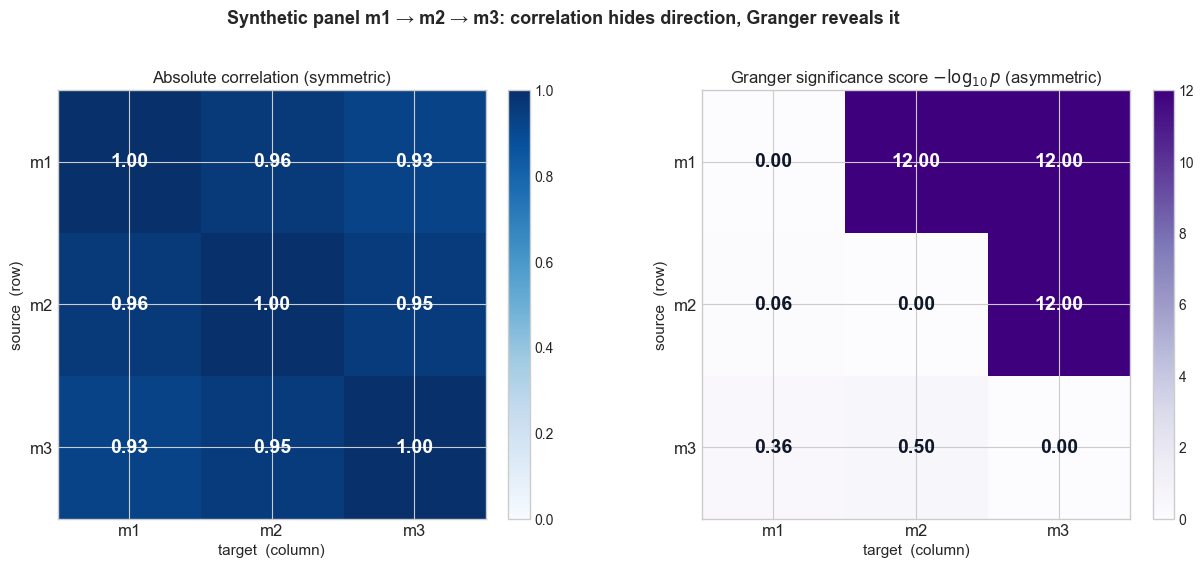

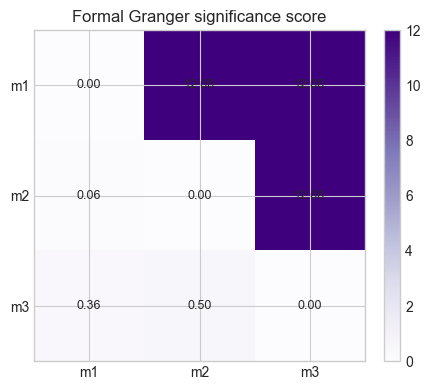


VAR diagnostics:
 selected_lag     aic     bic    hqic  is_stable  whiteness_pvalue
            1 -13.279 -13.222 -13.257       True             0.701

Top VAR causality edges:
source target  f_stat  p_value  var_score  significant
    m1     m2 464.085    0.000     12.000         True
    m2     m3 361.394    0.000     12.000         True
    m3     m2   0.774    0.379      0.421        False
    m3     m1   0.625    0.429      0.367        False
    m2     m1   0.130    0.719      0.143        False
    m1     m3   0.013    0.910      0.041        False

Top VAR coefficient-strength edges:
source target  abs_lag_weight
    m2     m3           0.383
    m1     m2           0.331
    m3     m1           0.020
    m3     m2           0.019
    m2     m1           0.010
    m1     m3           0.001

Held-out threshold comparison:
               precision  recall     f1    tp    fp    fn
global             0.980   0.576  0.726  49.0   1.0  36.0
context_aware      0.855   0.694  0.766  5

/Users/grigo/Knowledge/outputs/time-series-anomaly-training-days-3-5-polished/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)


In [26]:
panel_indexed = panel_df.set_index('timestamp')
train_cut = int(len(panel_indexed) * TRAIN_FRAC)
train_index = panel_indexed.index[:train_cut]
train_panel = panel_indexed.loc[train_index]

corr = pairwise_correlation_matrix(train_panel, metric_cols)
granger_score, granger_pvals, granger_lags, granger_fstats, granger_edges = granger_matrix(
    train_panel,
    metric_cols,
    maxlag=MAX_GRANGER_LAG,
)

print('Absolute correlation matrix (training slice):')
print(corr.round(3))
print()
print('Top formal Granger edges (training slice):')
print(granger_edges[['source', 'target', 'best_lag', 'f_stat', 'p_value', 'granger_score', 'significant']].head(6).round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, mat, title, cmap, vmax in [
    (axes[0], corr, 'Absolute correlation (symmetric)', 'Blues', 1.0),
    (axes[1], granger_score, 'Granger significance score $-\\log_{10} p$ (asymmetric)', 'Purples', max(1.0, float(granger_score.to_numpy().max()))),
]:
    im = ax.imshow(mat.values, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(metric_cols)), metric_cols, fontsize=12)
    ax.set_yticks(range(len(metric_cols)), metric_cols, fontsize=12)
    ax.set_xlabel('target  (column)', fontsize=11)
    ax.set_ylabel('source  (row)', fontsize=11)
    ax.set_title(title, fontsize=12)
    for i in range(len(metric_cols)):
        for j in range(len(metric_cols)):
            value = mat.iloc[i, j]
            text_color = 'white' if value > 0.55 * vmax else '#0f172a'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                    fontsize=14, fontweight='bold', color=text_color)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Synthetic panel m1 → m2 → m3: correlation hides direction, Granger reveals it',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day5_correlation_vs_direction.png', dpi=160, bbox_inches='tight')
plt.show()

granger_fig, granger_ax = plt.subplots(figsize=(5.2, 4.0))
im = granger_ax.imshow(granger_score.values, cmap='Purples', vmin=0, vmax=max(1.0, float(granger_score.to_numpy().max())))
granger_ax.set_xticks(range(len(metric_cols)), metric_cols)
granger_ax.set_yticks(range(len(metric_cols)), metric_cols)
granger_ax.set_title('Formal Granger significance score')
for i in range(len(metric_cols)):
    for j in range(len(metric_cols)):
        granger_ax.text(j, i, f'{granger_score.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
granger_fig.colorbar(im, ax=granger_ax, fraction=0.046, pad=0.04)
plt.tight_layout()
if EXPORT_FIGURES:
    granger_fig.savefig(FIG_DIR / 'day5_granger_direction_demo.png', dpi=160, bbox_inches='tight')
plt.show()

var_res, residuals, residual_score, var_diag = fit_var_and_residuals(
    panel_indexed,
    metric_cols,
    train_index=train_index,
    maxlags=MAX_VAR_LAG,
    ic='aic',
)
residual_train_index = residual_score.index.intersection(train_index)
var_strength = var_parent_strength_matrix(var_res, metric_cols)
var_strength_edges = edge_table_from_matrix(var_strength, 'abs_lag_weight')
var_score, var_pvals, var_edges = var_causality_table(var_res, metric_cols)

print()
print('VAR diagnostics:')
print(var_diag.round(3).to_string(index=False))
print()
print('Top VAR causality edges:')
print(var_edges[['source', 'target', 'f_stat', 'p_value', 'var_score', 'significant']].head(6).round(3).to_string(index=False))
print()
print('Top VAR coefficient-strength edges:')
print(var_strength_edges.head(6).round(3).to_string(index=False))

base_score = base_panel_score(panel_indexed, metric_cols).reindex(residual_score.index).fillna(0.0)
context = panel_indexed['context'].reindex(residual_score.index)
labels = panel_indexed['is_anomaly'].reindex(residual_score.index).fillna(0).astype(int)

fused_score = 0.70 * zscore(residual_score) + 0.30 * zscore(base_score)
global_threshold = float(fused_score.loc[residual_train_index].quantile(0.99))
context_threshold = context_thresholds(fused_score, context, residual_train_index, q=0.99)

global_alert = (fused_score > global_threshold).astype(int)
context_alert = (fused_score > context_threshold).astype(int)

summary = pd.DataFrame({
    'fused_score': fused_score,
    'global_threshold': global_threshold,
    'context_threshold': context_threshold,
    'global_alert': global_alert,
    'context_alert': context_alert,
    'label': labels,
    'context': context,
})

test_index = summary.index[~summary.index.isin(residual_train_index)]
comparison_df = pd.DataFrame({
    'global': point_metrics(summary.loc[test_index, 'label'].to_numpy(), summary.loc[test_index, 'global_alert'].to_numpy()),
    'context_aware': point_metrics(summary.loc[test_index, 'label'].to_numpy(), summary.loc[test_index, 'context_alert'].to_numpy()),
}).T
print()
print('Held-out threshold comparison:')
print(comparison_df.round(3))
print()
print('Training thresholds by regime:')
print(context_threshold.groupby(context).first().round(3))


Held-out event review:
 event_id               start                 end      peak_timestamp  peak_score  context dominant_metric  max_abs_residual granger_upstream var_parent_candidate upstream_candidate  granger_pvalue  var_parent_strength
        1 2024-01-01 17:30:00 2024-01-01 23:05:00 2024-01-01 22:20:00    5.980095 low_load              m3          1.138383               m2                   m2                 m2   3.468354e-118             0.383402

Context-graph-style edge rows:
 event_id     context_node source_node target_node  var_parent_strength  granger_score      peak_timestamp
        1 context:low_load          m2          m3             0.383402           12.0 2024-01-01 22:20:00
        1 context:low_load          m1          m3             0.001487           12.0 2024-01-01 22:20:00

Optional PCMCI comparison (training slice, top links):
source target  lag edge  p_value  effect
    m2     m3    1  -->      0.0    0.40
    m1     m2    1  -->      0.0    0.35


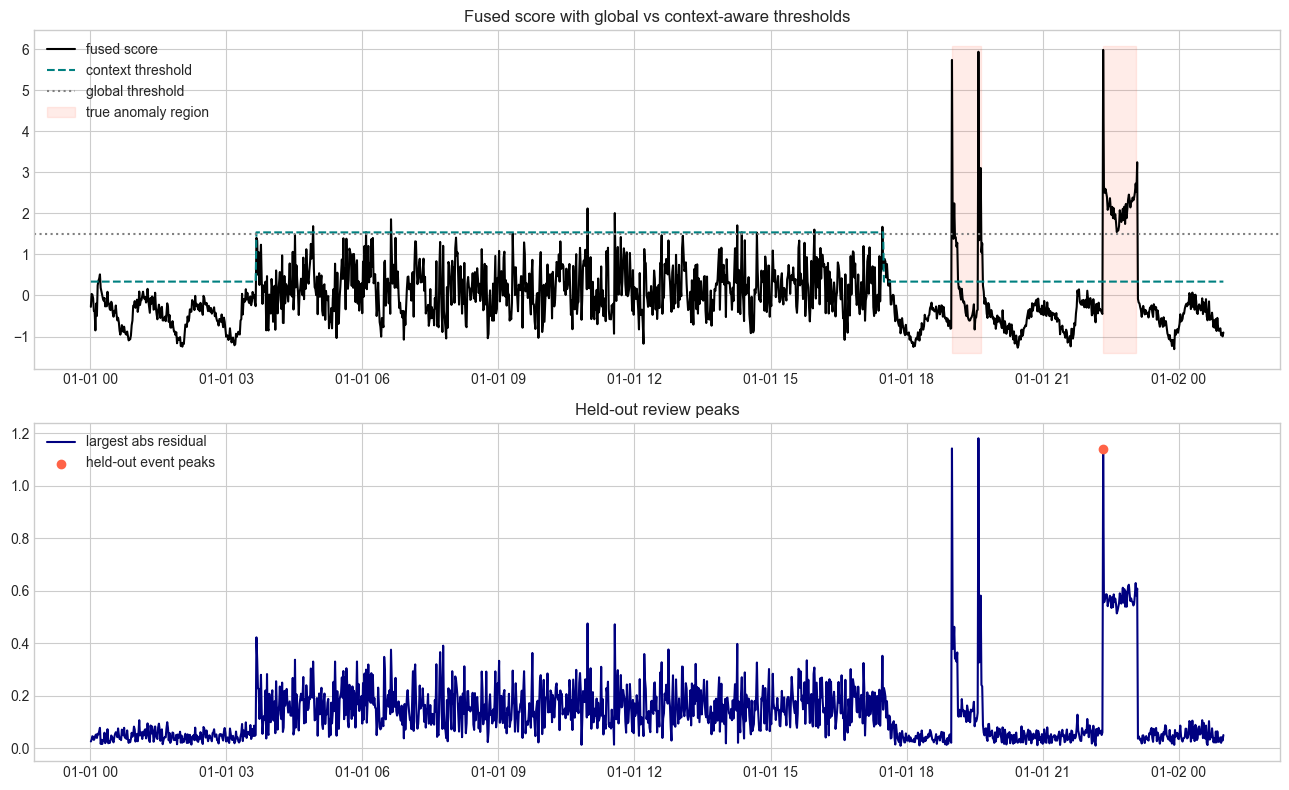

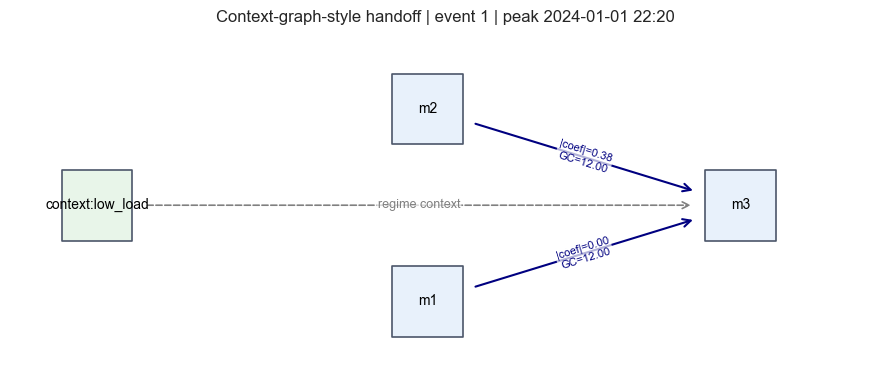

In [27]:
heldout_report = heldout_event_report(
    summary,
    residuals,
    granger_pvals,
    var_strength,
    var_pvals,
    test_index,
    alpha_level=ALPHA_LEVEL,
    top_k=8,
)
print('Held-out event review:')
print(heldout_report.to_string(index=False))
print()

context_graph_df = build_context_graph_rows(heldout_report, granger_score, var_strength, top_edges=2)
print('Context-graph-style edge rows:')
print(context_graph_df.to_string(index=False))
print()

if TIGRAMITE_AVAILABLE:
    pcmci_edges = run_pcmci_link_table(
        train_panel,
        metric_cols,
        tau_max=MAX_GRANGER_LAG,
        alpha_level=ALPHA_LEVEL,
        pc_alpha=PCMCI_PC_ALPHA,
    )
    if pcmci_edges.empty:
        print('Optional PCMCI comparison: no significant lagged links at the chosen alpha level.')
    else:
        print('Optional PCMCI comparison (training slice, top links):')
        print(pcmci_edges.head(6).round(3).to_string(index=False))
else:
    print('Optional PCMCI comparison skipped: install tigramite to enable this branch.')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
axes[0].plot(summary.index, summary['fused_score'], label='fused score', color='black')
axes[0].plot(summary.index, summary['context_threshold'], label='context threshold', linestyle='--', color='teal')
axes[0].axhline(global_threshold, label='global threshold', linestyle=':', color='gray')
axes[0].fill_between(
    summary.index,
    summary['fused_score'].min() - 0.1,
    summary['fused_score'].max() + 0.1,
    where=summary['label'].astype(bool),
    color='tomato',
    alpha=0.12,
    label='true anomaly region',
)
axes[0].legend(loc='upper left')
axes[0].set_title('Fused score with global vs context-aware thresholds')

axes[1].plot(summary.index, residuals.abs().max(axis=1), label='largest abs residual', color='navy')
if not heldout_report.empty:
    axes[1].scatter(heldout_report['peak_timestamp'], heldout_report['max_abs_residual'], color='tomato', label='held-out event peaks', zorder=3)
axes[1].legend(loc='upper left')
axes[1].set_title('Held-out review peaks')
plt.tight_layout()
if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / 'day5_contextual_alerts.png', dpi=160, bbox_inches='tight')
plt.show()

if not heldout_report.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_event_context_graph(heldout_report.iloc[0], granger_score, var_strength, ax=ax, top_edges=2)
    plt.tight_layout()
    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'day5_context_graph_notebook.png', dpi=160, bbox_inches='tight')
    plt.show()


## Interpretation checkpoint

Expected synthetic-demo pattern:
- raw correlation should look broad and symmetric, while the formal **Granger** matrix should be more selective,
- the **VAR** parent-strength and causality views should help recover a plausible upstream path for the dominant alert metric,
- context-aware thresholding should change the held-out alert profile relative to a single global threshold,
- and the final event report should distinguish **Granger upstream**, **VAR parent candidate**, and the final **upstream candidate** used for handoff.

## Exercises
1. Increase the Granger / VAR lag depth from 3 to 5. Do the strongest edges stay stable?
2. Remove the context variable and compare the thresholding behavior.
3. Compare the pairwise Granger matrix with the VAR causality table. Where do they disagree?
4. Add a second context variable and extend the context-graph-style report.
5. Discuss what extra evidence would be required before calling the upstream candidate a root cause.
6. If Tigramite / PCMCI is available, compare its top lagged links against the pairwise Granger view.
